# 11-1. 종일 음이항 NB2 회귀분석

## 음이항 회귀를 사용하는 이유
승차인원은 0 이상의 정수형 빈도 자료이다. Poisson 모형은 조건부 평균과 분산이 같다고 가정하지만, 본 자료에서 분산이 평균보다 크게 나타나 과대산포가 확인되었다. 따라서 과대산포를 허용하는 음이항 NB2 모형을 사용한다.

NB2의 분산은 $Var(Y_i|X_i)=\mu_i+\alpha\mu_i^2$이며, $\alpha>0$이면 분산이 평균보다 크다.

2024년 승차인원은 일반 독립변수가 아니라 offset으로 넣어 2024년 대비 2025년 변화율을 추정한다. 노선 고정효과와 셀 단위 군집 강건 표준오차를 적용한다.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0,str(Path.cwd().parent))
from config import *
setup_notebook()
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial
from IPython.display import display
data=load_model_data(); f=load_cell_route_all_day()
X_FINAL=['walk_20','walk_20_60','ic_access','competing_share','pop_20_50','buildings']; CONT=['ic_access','competing_share','pop_20_50','buildings']
f['셀 ID']=f['셀 ID'].astype(int); f=f.merge(data[['셀 ID']+X_FINAL],on='셀 ID'); f=f[f.y2024>0].reset_index(drop=True)
x=f[X_FINAL].copy()
for c in CONT:
    sd=x[c].std(ddof=0); x[c]=(x[c]-x[c].mean())/(sd if sd else 1)
route=pd.get_dummies(f['노선'],prefix='노선',drop_first=True,dtype=float); X=sm.add_constant(pd.concat([x,route],axis=1),has_constant='add'); offset=np.log(f.y2024)
print('종일 셀×노선:',len(f),'개 | 셀:',f['셀 ID'].nunique(),'개 | 노선:',f['노선'].nunique(),'개')
print('2025 승차인원 평균:',round(f.y2025.mean(),4))
print('2025 승차인원 분산:',round(f.y2025.var(ddof=1),4))
print('단순 자료 분산/평균:',round(f.y2025.var(ddof=1)/f.y2025.mean(),4))

종일 셀×노선: 220 개 | 셀: 132 개 | 노선: 24 개
2025 승차인원 평균: 74.0909
2025 승차인원 분산: 21581.1059
단순 자료 분산/평균: 291.2787


## 1. 과대산포 진단

Pearson dispersion과 deviance/df가 1보다 크게 높으면 Poisson의 평균=분산 가정이 적절하지 않을 가능성이 있다.

In [2]:
pois=sm.GLM(f.y2025,X,family=sm.families.Poisson(),offset=offset).fit()
print('Poisson Pearson dispersion:',round(pois.pearson_chi2/pois.df_resid,4))
print('Poisson deviance/df:',round(pois.deviance/pois.df_resid,4))

Poisson Pearson dispersion: 14.2229
Poisson deviance/df: 12.216


## 2. 음이항 NB2 추정 및 적합도

In [3]:
nb=NegativeBinomial(f.y2025,X,offset=offset,loglike_method='nb2'); start=np.r_[np.asarray(pois.params),0.5]
nb_fit=nb.fit(start_params=start,method='bfgs',maxiter=5000,disp=False,cov_type='cluster',cov_kwds={'groups':pd.factorize(f['셀 ID'])[0],'use_correction':True})
print('converged =',nb_fit.mle_retvals.get('converged')); print('warnflag =',nb_fit.mle_retvals.get('warnflag'))
assert nb_fit.mle_retvals.get('converged') is True and nb_fit.mle_retvals.get('warnflag',0)==0
alpha=float(nb_fit.params.iloc[-1] if hasattr(nb_fit.params,'iloc') else nb_fit.params[-1])
null=NegativeBinomial(f.y2025,np.ones((len(f),1)),offset=offset,loglike_method='nb2'); null_fit=null.fit(start_params=np.array([np.log(f.y2025.sum()/f.y2024.sum()),0.5]),method='bfgs',maxiter=5000,disp=False)
fit_table=pd.DataFrame({'표본 수':[len(f)],'로그우도':[nb_fit.llf],'Null 로그우도':[null_fit.llf],'McFadden pseudo R²':[1-nb_fit.llf/null_fit.llf],'AIC':[nb_fit.aic],'BIC':[nb_fit.bic],'alpha':[alpha]}).round(4)
display(fit_table)
print('NB2 조건부 분산: Var(Y|X)=mu + alpha*mu^2')
print('alpha=',round(alpha,4),'이므로 조건부 분산이 평균보다 큰 과대산포 모형이다.')

converged = True
warnflag = 0


,표본 수,로그우도,Null 로그우도,McFadden pseudo R²,AIC,BIC,alpha
0,220,-938.4253,-989.6589,0.0518,1938.8505,2044.053,0.2193


NB2 조건부 분산: Var(Y|X)=mu + alpha*mu^2
alpha= 0.2193 이므로 조건부 분산이 평균보다 큰 과대산포 모형이다.


## 3. 음이항 NB2 계수·효과·p-value

In [4]:
ci=nb_fit.conf_int().loc[X_FINAL]
out=pd.DataFrame({'변수':[VARIABLE_LABELS.get(v,v) for v in X_FINAL],'계수':[nb_fit.params[v] for v in X_FINAL],'변화율(%)':[(np.exp(nb_fit.params[v])-1)*100 for v in X_FINAL],'95% CI 하한(%)':[(np.exp(ci.loc[v,0])-1)*100 for v in X_FINAL],'95% CI 상한(%)':[(np.exp(ci.loc[v,1])-1)*100 for v in X_FINAL],'p-value':[nb_fit.pvalues[v] for v in X_FINAL]})
display(out.round({'계수':4,'변화율(%)':2,'95% CI 하한(%)':2,'95% CI 상한(%)':2,'p-value':4}))
print('연속형 변수는 1표준편차 증가 기준이다.')

,변수,계수,변화율(%),95% CI 하한(%),95% CI 상한(%),p-value
0,보행 20분 이내,-0.7980,-54.98,-71.47,-28.95,0.0006
1,보행 20~60분,-0.4890,-38.68,-58.48,-9.43,0.0140
2,IC까지 도로거리(km),-0.1716,-15.77,-26.05,-4.05,0.0098
3,GTX 경쟁 목적지 비율(%),-0.1186,-11.18,-22.32,1.56,0.0830
4,2024년 20~50대 인구,-0.0316,-3.12,-13.75,8.83,0.5938
5,2024년 건축물 수,-0.1059,-10.05,-18.54,-0.67,0.0363


연속형 변수는 1표준편차 증가 기준이다.


In [5]:
# 선행연구 Table 3 형식의 최종 결과표
paper_table = pd.DataFrame({
    'Variable': [VARIABLE_LABELS.get(v, v) for v in X_FINAL],
    'coef (p-value)': [f'{nb_fit.params[v]:.4f} ({nb_fit.pvalues[v]:.4f})' for v in X_FINAL],
    '변화율(%)': [(np.exp(nb_fit.params[v]) - 1) * 100 for v in X_FINAL],
})
display(paper_table.round({'변화율(%)': 2}))

model_summary = pd.DataFrame({
    '표본 수': [len(f)],
    'McFadden pseudo R²': [1 - nb_fit.llf / null_fit.llf],
    'AIC': [nb_fit.aic],
    'BIC': [nb_fit.bic],
    'alpha': [alpha],
    'converged': [nb_fit.mle_retvals.get('converged')],
})
display(model_summary.round(4))


,Variable,coef (p-value),변화율(%)
0,보행 20분 이내,-0.7980 (0.0006),-54.98
1,보행 20~60분,-0.4890 (0.0140),-38.68
2,IC까지 도로거리(km),-0.1716 (0.0098),-15.77
3,GTX 경쟁 목적지 비율(%),-0.1186 (0.0830),-11.18
4,2024년 20~50대 인구,-0.0316 (0.5938),-3.12
5,2024년 건축물 수,-0.1059 (0.0363),-10.05


,표본 수,McFadden pseudo R²,AIC,BIC,alpha,converged
0,220,0.0518,1938.8505,2044.053,0.2193,True


In [6]:
# 논문용 음이항 회귀 결과표
ci=nb_fit.conf_int().loc[X_FINAL]
paper_result = pd.DataFrame({
    '변수': [VARIABLE_LABELS.get(v, v) for v in X_FINAL],
    '계수': [nb_fit.params[v] for v in X_FINAL],
    '표준오차': [nb_fit.bse[v] for v in X_FINAL],
    'z값': [nb_fit.params[v] / nb_fit.bse[v] for v in X_FINAL],
    'p-value': [nb_fit.pvalues[v] for v in X_FINAL],
    '95% CI 하한': [ci.loc[v, 0] for v in X_FINAL],
    '95% CI 상한': [ci.loc[v, 1] for v in X_FINAL],
    'IRR': [np.exp(nb_fit.params[v]) for v in X_FINAL],
    '변화율(%)': [(np.exp(nb_fit.params[v]) - 1) * 100 for v in X_FINAL],
})
display(paper_result.round({'계수':4,'표준오차':4,'z값':3,'p-value':4,'95% CI 하한':4,'95% CI 상한':4,'IRR':4,'변화율(%)':2}))
print('주: 연속형 변수는 1표준편차 증가 기준이며, 기준집단은 GTX 보행 60분 초과이다.')


,변수,계수,표준오차,z값,p-value,95% CI 하한,95% CI 상한,IRR,변화율(%)
0,보행 20분 이내,-0.7980,0.2327,-3.429,0.0006,-1.2542,-0.3419,0.4502,-54.98
1,보행 20~60분,-0.4890,0.1989,-2.458,0.0140,-0.8789,-0.0991,0.6132,-38.68
2,IC까지 도로거리(km),-0.1716,0.0665,-2.582,0.0098,-0.3018,-0.0414,0.8423,-15.77
3,GTX 경쟁 목적지 비율(%),-0.1186,0.0684,-1.733,0.0830,-0.2526,0.0155,0.8882,-11.18
4,2024년 20~50대 인구,-0.0316,0.0593,-0.533,0.5938,-0.1479,0.0847,0.9688,-3.12
5,2024년 건축물 수,-0.1059,0.0506,-2.093,0.0363,-0.2050,-0.0067,0.8995,-10.05


주: 연속형 변수는 1표준편차 증가 기준이며, 기준집단은 GTX 보행 60분 초과이다.


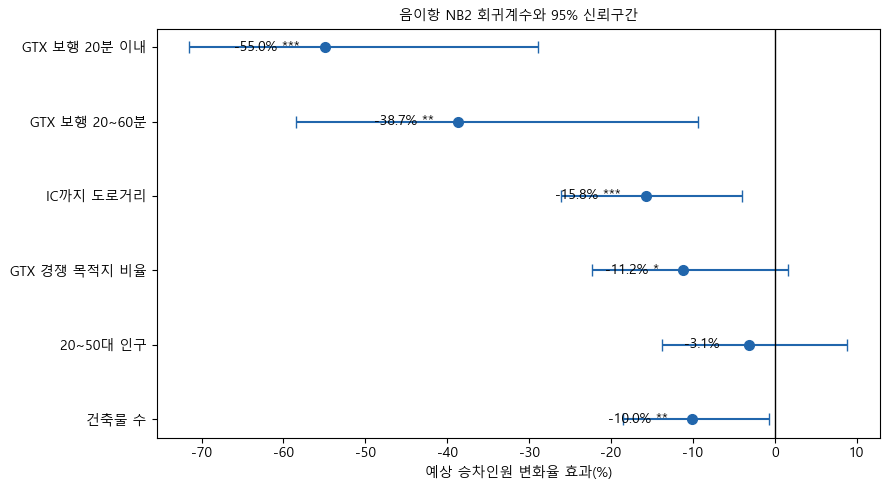

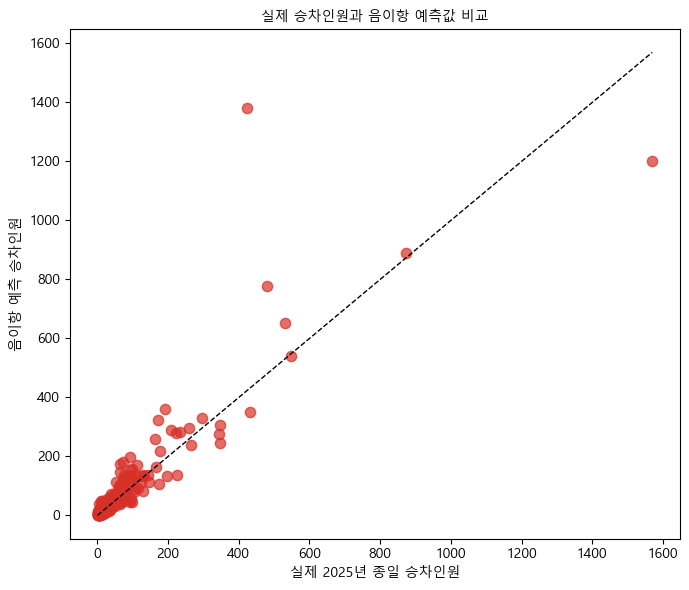

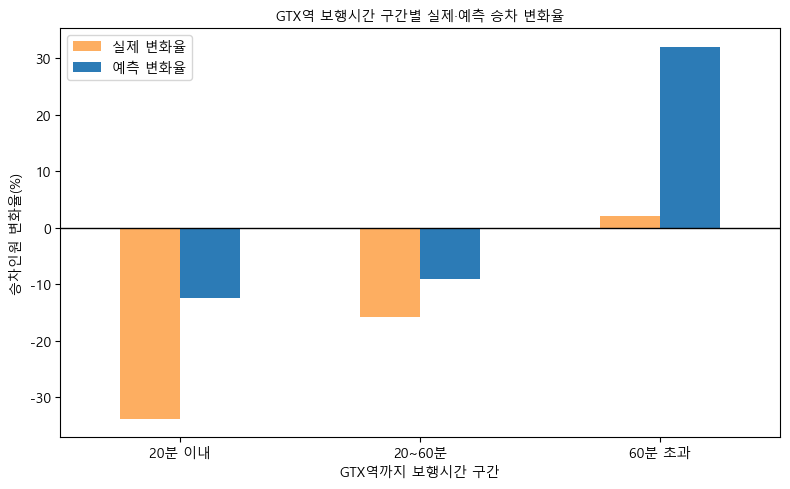

In [7]:
# 음이항 NB2 결과 시각화
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = Path(r"C:\Windows\Fonts\malgun.ttf")
font_prop = fm.FontProperties(fname=str(font_path))
fm.fontManager.addfont(str(font_path))
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

LABELS = {
    'walk_20': 'GTX 보행 20분 이내',
    'walk_20_60': 'GTX 보행 20~60분',
    'ic_access': 'IC까지 도로거리',
    'competing_share': 'GTX 경쟁 목적지 비율',
    'pop_20_50': '20~50대 인구',
    'buildings': '건축물 수',
}

# 1. 변수별 변화율 효과와 95% 신뢰구간
ci = nb_fit.conf_int().loc[X_FINAL]
effect_table = pd.DataFrame({
    '변수': [LABELS.get(v, v) for v in X_FINAL],
    '계수': nb_fit.params.loc[X_FINAL].values,
    '하한': ci[0].values,
    '상한': ci[1].values,
    'p-value': nb_fit.pvalues.loc[X_FINAL].values,
})
effect_table['효과(%)'] = (np.exp(effect_table['계수']) - 1) * 100
effect_table['하한(%)'] = (np.exp(effect_table['하한']) - 1) * 100
effect_table['상한(%)'] = (np.exp(effect_table['상한']) - 1) * 100
effect_table = effect_table.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(effect_table))
x = effect_table['효과(%)'].to_numpy()
xerr = np.vstack([
    x - effect_table['하한(%)'].to_numpy(),
    effect_table['상한(%)'].to_numpy() - x,
])
ax.errorbar(x, y_pos, xerr=xerr, fmt='o', color='#2166ac',
            ecolor='#2166ac', capsize=4, markersize=7)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(effect_table['변수'].tolist(), fontproperties=font_prop)
ax.set_xlabel('예상 승차인원 변화율 효과(%)', fontproperties=font_prop)
ax.set_title('음이항 NB2 회귀계수와 95% 신뢰구간', fontproperties=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for i, row in effect_table.iterrows():
    p = row['p-value']
    mark = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    effect = row['효과(%)']
    ax.text(effect + (3 if effect >= 0 else -3), i,
            f'{effect:.1f}% {mark}', va='center',
            ha='left' if effect >= 0 else 'right',
            fontproperties=font_prop)
plt.tight_layout()
plt.show()

# 2. 실제값과 예측값 산점도
f_plot = f.copy()
f_plot['예측_2025승차인원'] = nb_fit.predict(X, offset=offset)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(f_plot['y2025'], f_plot['예측_2025승차인원'],
           s=55, alpha=0.7, color='#d73027')
max_value = max(f_plot['y2025'].max(), f_plot['예측_2025승차인원'].max())
ax.plot([0, max_value], [0, max_value], '--', color='black', linewidth=1)
ax.set_xlabel('실제 2025년 종일 승차인원', fontproperties=font_prop)
ax.set_ylabel('음이항 예측 승차인원', fontproperties=font_prop)
ax.set_title('실제 승차인원과 음이항 예측값 비교', fontproperties=font_prop)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font_prop)
plt.tight_layout()
plt.show()

# 3. GTX 보행시간 구간별 실제·예측 변화율
f_plot['보행시간 구간'] = np.select(
    [f_plot['walk_20'] == 1, f_plot['walk_20_60'] == 1],
    ['20분 이내', '20~60분'],
    default='60분 초과'
)
actual_rate = f_plot.groupby('보행시간 구간').apply(
    lambda g: (g['y2025'].sum() / g['y2024'].sum() - 1) * 100
)
predicted_rate = f_plot.groupby('보행시간 구간').apply(
    lambda g: (g['예측_2025승차인원'].sum() / g['y2024'].sum() - 1) * 100
)
plot_df = pd.DataFrame({
    '실제 변화율': actual_rate,
    '예측 변화율': predicted_rate,
}).reindex(['20분 이내', '20~60분', '60분 초과'])

ax = plot_df.plot(kind='bar', figsize=(8, 5), color=['#fdae61', '#2c7bb6'])
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('GTX역까지 보행시간 구간', fontproperties=font_prop)
ax.set_ylabel('승차인원 변화율(%)', fontproperties=font_prop)
ax.set_title('GTX역 보행시간 구간별 실제·예측 승차 변화율', fontproperties=font_prop)
ax.legend(prop=font_prop)
ax.set_xticklabels(['20분 이내', '20~60분', '60분 초과'], rotation=0,
                   fontproperties=font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
plt.tight_layout()
plt.show()


In [8]:

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 설치된 한글 폰트를 찾아 설정합니다.
available_fonts = {font.name for font in fm.fontManager.ttflist}
font_candidates = [
    'Malgun Gothic',
    '맑은 고딕',
    'NanumGothic',
    'Noto Sans CJK KR',
    'AppleGothic'
]

korean_font = next(
    (font for font in font_candidates if font in available_fonts),
    None
)

if korean_font is None:
    raise RuntimeError(
        '한글 폰트를 찾을 수 없습니다. Windows에서는 맑은 고딕(Malgun Gothic)을 설치한 뒤 '
        '커널을 재시작하고 다시 실행하세요.'
    )

sns.set_style('whitegrid')
plt.rcParams['font.family'] = korean_font
plt.rcParams['axes.unicode_minus'] = False

print(f'그래프 폰트: {korean_font}')


그래프 폰트: Malgun Gothic


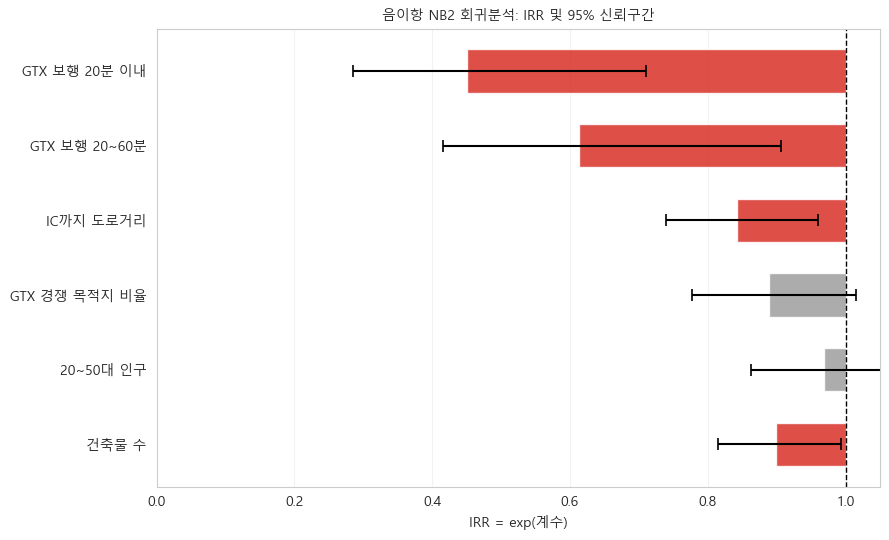

In [9]:
# 음이항 NB2 결과 시각화: IRR과 95% 신뢰구간만 표시
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = Path(r"C:\Windows\Fonts\malgun.ttf")
font_prop = fm.FontProperties(fname=str(font_path))
fm.fontManager.addfont(str(font_path))
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

LABELS = {
    'walk_20': 'GTX 보행 20분 이내',
    'walk_20_60': 'GTX 보행 20~60분',
    'ic_access': 'IC까지 도로거리',
    'competing_share': 'GTX 경쟁 목적지 비율',
    'pop_20_50': '20~50대 인구',
    'buildings': '건축물 수',
}

ci = nb_fit.conf_int().loc[X_FINAL]
irr_table = pd.DataFrame({
    '변수': [LABELS.get(v, v) for v in X_FINAL],
    'IRR': np.exp(nb_fit.params.loc[X_FINAL].values),
    'IRR 하한': np.exp(ci[0].values),
    'IRR 상한': np.exp(ci[1].values),
    'p-value': nb_fit.pvalues.loc[X_FINAL].values,
}).iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(irr_table))
x = irr_table['IRR'].to_numpy()
xerr = np.vstack([
    x - irr_table['IRR 하한'].to_numpy(),
    irr_table['IRR 상한'].to_numpy() - x,
])
colors = ['#d73027' if p < 0.05 else '#9e9e9e' for p in irr_table['p-value']]

ax.barh(y, x - 1, left=1, color=colors, alpha=0.85, height=0.58)
ax.errorbar(x, y, xerr=xerr, fmt='none', ecolor='black', capsize=4,
            elinewidth=1.5, capthick=1.2)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_xlim(0, 1.05)
ax.set_yticks(y)
ax.set_yticklabels(irr_table['변수'].tolist(), fontproperties=font_prop)
ax.set_xlabel('IRR = exp(계수)', fontproperties=font_prop)
ax.set_title('음이항 NB2 회귀분석: IRR 및 95% 신뢰구간', fontproperties=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()


## 포아송 모형과 음이항 모형의 우도비 검정

귀무가설은 alpha=0이며, 이 경우 음이항 모형이 포아송 모형으로 축약된다. alpha=0이 경계값이므로 혼합 카이제곱 분포를 사용한다.

In [10]:
from scipy.stats import chi2

# pois와 nb_fit은 동일 표본·변수·offset·노선 고정효과로 추정된 결과를 사용
lr_stat = 2 * (nb_fit.llf - pois.llf)
# alpha=0이 경계값이므로 0.5 * chi-square(1) p-value
lr_pvalue = 0.5 * chi2.sf(lr_stat, 1)

print(f'Poisson log-likelihood: {pois.llf:.4f}')
print(f'Negative Binomial log-likelihood: {nb_fit.llf:.4f}')
print(f'LR statistic: {lr_stat:.4f}')
print(f'LR Test of alpha=0 p-value: {lr_pvalue:.6g}')
print('결론:', 'alpha=0 기각 → 음이항 모형 지지' if lr_pvalue < 0.05 else 'alpha=0 기각 실패 → 포아송 모형과 차이 불충분')


Poisson log-likelihood: -1733.1043
Negative Binomial log-likelihood: -938.4253
LR statistic: 1589.3580
LR Test of alpha=0 p-value: 0
결론: alpha=0 기각 → 음이항 모형 지지


## 음이항 모형의 alpha 유의성 검정

alpha가 0보다 유의하게 큰지 확인한다.

In [11]:
alpha_name = 'alpha'
alpha_hat = float(nb_fit.params.iloc[-1] if hasattr(nb_fit.params, "iloc") else nb_fit.params[-1])
alpha_p = float(nb_fit.pvalues.iloc[-1] if hasattr(nb_fit.pvalues, "iloc") else nb_fit.pvalues[-1])
print(f'alpha coefficient: {alpha_hat:.4f}')
print(f'alpha coefficient p-value: {alpha_p:.6g}')
print('결론:', 'alpha가 0보다 유의하게 큼 → 과산포 확인' if alpha_p < 0.05 else 'alpha가 0보다 유의하지 않음 → 포아송 모형과 비교 필요')


alpha coefficient: 0.2193
alpha coefficient p-value: 3.04326e-09
결론: alpha가 0보다 유의하게 큼 → 과산포 확인



# 11-2. 음이항 NB2 최종모형 튜닝

이 노트북은 11-1의 기존 최종모형을 기준모형으로 유지한 뒤, 변수 조합과 노선 고정효과 설정을 바꾸어 결과의 안정성을 비교한다.

- 기준모형: 보행시간 구간 + IC 도로거리 + 경쟁 목적지 비율 + 20~50대 인구 + 건축물 수 + 노선 고정효과
- 종속변수: 2025년 종일 승차인원
- offset: log(2024년 종일 승차인원)
- 표준오차: 셀 ID 기준 군집 강건 표준오차
- 모형: 음이항 NB2

튜닝의 목적은 유의한 변수를 억지로 만드는 것이 아니라, 이론적으로 필요한 변수를 유지하면서 모형의 간결성·적합도·계수 안정성을 비교하는 것이다.


In [12]:
# 11-1의 기준모형과 별도로 튜닝에 필요한 라이브러리와 함수
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial
from IPython.display import display

warnings.filterwarnings('ignore')

# 11-1에서 이미 생성된 f, X_FINAL, CONT, offset, nb_fit을 사용한다.
assert 'f' in globals() and 'X_FINAL' in globals() and 'offset' in globals()

BASE_FEATURES = ['walk_20', 'walk_20_60', 'ic_access',
            'competing_share', 'pop_20_50', 'buildings']
CONTINUOUS = ['ic_access', 'competing_share', 'pop_20_50', 'buildings']

print('기준 데이터:', len(f), '개 셀×노선 관측치')
print('격자 수:', f['셀 ID'].nunique(), '개')
print('노선 수:', f['노선'].nunique(), '개')
print('기준 변수:', BASE_FEATURES)


기준 데이터: 220 개 셀×노선 관측치
격자 수: 132 개
노선 수: 24 개
기준 변수: ['walk_20', 'walk_20_60', 'ic_access', 'competing_share', 'pop_20_50', 'buildings']


In [13]:
def build_design(frame, features, route_fe=True, standardize=True):
    """튜닝용 설계행렬 생성. 연속형 변수 표준화 여부를 선택할 수 있다."""
    x = frame[features].copy().astype(float)
    if standardize:
        for col in [c for c in CONTINUOUS if c in x.columns]:
            sd = x[col].std(ddof=0)
            x[col] = (x[col] - x[col].mean()) / (sd if sd else 1.0)
    if route_fe:
        route = pd.get_dummies(frame['노선'], prefix='노선', drop_first=True, dtype=float)
        x = pd.concat([x, route], axis=1)
    return sm.add_constant(x, has_constant='add')


def fit_nb2_variant(name, features, route_fe=True, standardize=True):
    """같은 표본과 offset으로 NB2 모형을 적합한다."""
    Xv = build_design(f, features, route_fe=route_fe, standardize=standardize)
    pois = sm.GLM(f['y2025'], Xv, family=sm.families.Poisson(), offset=offset).fit()
    start = np.r_[np.asarray(pois.params), 0.2]
    model = NegativeBinomial(f['y2025'], Xv, offset=offset, loglike_method='nb2')
    fit = model.fit(
        start_params=start, method='bfgs', maxiter=5000, disp=False,
        cov_type='cluster',
        cov_kwds={'groups': pd.factorize(f['셀 ID'])[0], 'use_correction': True}
    )
    return fit, Xv


# 상수항만 포함한 NB2 기준모형. McFadden pseudo-R² 계산용
X_null = np.ones((len(f), 1))
null_model = NegativeBinomial(f['y2025'], X_null, offset=offset, loglike_method='nb2')
null_start = np.array([np.log(f['y2025'].sum() / f['y2024'].sum()), 0.2])
null_fit = null_model.fit(start_params=null_start, method='bfgs', maxiter=5000, disp=False)


## 튜닝할 모형 목록

아래 목록의 변수 조합을 수정해서 추가 모형을 시험할 수 있다. 기준모형은 반드시 포함하고, 비교모형은 이론적 근거가 있는 경우에만 추가한다.

In [14]:
VARIANT_SPECS = {
    '기준모형_전체변수': {
        'features': BASE_FEATURES, 'route_fe': True, 'standardize': True,
    },
    '핵심모형_보행_IC': {
        'features': ['walk_20', 'walk_20_60', 'ic_access'],
        'route_fe': True, 'standardize': True,
    },
    '건축물수_제외': {
        'features': ['walk_20', 'walk_20_60', 'ic_access',
                     'competing_share', 'pop_20_50'],
        'route_fe': True, 'standardize': True,
    },
    '경쟁목적지_제외': {
        'features': ['walk_20', 'walk_20_60', 'ic_access',
                     'pop_20_50', 'buildings'],
        'route_fe': True, 'standardize': True,
    },
    '노선고정효과_제외': {
        'features': BASE_FEATURES, 'route_fe': False, 'standardize': True,
    },
    '표준화_제외_참고': {
        'features': BASE_FEATURES, 'route_fe': True, 'standardize': False,
    },
}

print('비교할 모형 수:', len(VARIANT_SPECS))
for name, spec in VARIANT_SPECS.items():
    print(name, '=>', spec)


비교할 모형 수: 6
기준모형_전체변수 => {'features': ['walk_20', 'walk_20_60', 'ic_access', 'competing_share', 'pop_20_50', 'buildings'], 'route_fe': True, 'standardize': True}
핵심모형_보행_IC => {'features': ['walk_20', 'walk_20_60', 'ic_access'], 'route_fe': True, 'standardize': True}
건축물수_제외 => {'features': ['walk_20', 'walk_20_60', 'ic_access', 'competing_share', 'pop_20_50'], 'route_fe': True, 'standardize': True}
경쟁목적지_제외 => {'features': ['walk_20', 'walk_20_60', 'ic_access', 'pop_20_50', 'buildings'], 'route_fe': True, 'standardize': True}
노선고정효과_제외 => {'features': ['walk_20', 'walk_20_60', 'ic_access', 'competing_share', 'pop_20_50', 'buildings'], 'route_fe': False, 'standardize': True}
표준화_제외_참고 => {'features': ['walk_20', 'walk_20_60', 'ic_access', 'competing_share', 'pop_20_50', 'buildings'], 'route_fe': True, 'standardize': False}


In [15]:
fit_results = {}
summary_rows = []

for name, spec in VARIANT_SPECS.items():
    try:
        fit, Xv = fit_nb2_variant(name, **spec)
        converged = bool(fit.mle_retvals.get('converged', False))
        warnflag = fit.mle_retvals.get('warnflag', np.nan)
        alpha = float(fit.params.iloc[-1] if hasattr(fit.params, 'iloc') else fit.params[-1])
        pseudo_r2 = 1 - fit.llf / null_fit.llf
        summary_rows.append({
            '모형': name,
            '표본 수': len(f),
            '변수 수': len(spec['features']),
            '노선 FE': '포함' if spec['route_fe'] else '제외',
            '표준화': '적용' if spec['standardize'] else '미적용',
            '로그우도': fit.llf,
            'McFadden pseudo R²': pseudo_r2,
            'AIC': fit.aic,
            'BIC': fit.bic,
            'alpha': alpha,
            'converged': converged,
            'warnflag': warnflag,
        })
        fit_results[name] = {'fit': fit, 'X': Xv, 'spec': spec}
    except Exception as exc:
        summary_rows.append({
            '모형': name, '표본 수': len(f),
            '변수 수': len(spec['features']),
            '노선 FE': '포함' if spec['route_fe'] else '제외',
            '표준화': '적용' if spec['standardize'] else '미적용',
            '로그우도': np.nan, 'McFadden pseudo R²': np.nan,
            'AIC': np.nan, 'BIC': np.nan, 'alpha': np.nan,
            'converged': False, 'warnflag': str(exc),
        })
        print(f'[실패] {name}: {exc}')

tuning_summary = pd.DataFrame(summary_rows)
display(tuning_summary.sort_values('AIC').round(4))


,모형,표본 수,변수 수,노선 FE,표준화,로그우도,McFadden pseudo R²,AIC,BIC,alpha,converged,warnflag
5,표준화_제외_참고,220,6,포함,미적용,-938.4253,0.0518,1938.8505,2044.0530,0.2193,True,0
0,기준모형_전체변수,220,6,포함,적용,-938.4253,0.0518,1938.8505,2044.0530,0.2193,True,0
3,경쟁목적지_제외,220,5,포함,적용,-940.1406,0.0500,1940.2813,2042.0901,0.2253,True,0
1,핵심모형_보행_IC,220,3,포함,적용,-942.8437,0.0473,1941.6875,2036.7091,0.2298,True,0
2,건축물수_제외,220,5,포함,적용,-941.4254,0.0487,1942.8508,2044.6596,0.2248,True,0
4,노선고정효과_제외,220,6,제외,적용,-977.4012,0.0124,1970.8024,1997.9514,0.3406,True,0


## 핵심 변수 계수와 p-value 비교

모형 적합도만으로 최종모형을 고르지 않고, 보행시간·IC 거리 등 핵심 변수의 방향과 유의성이 유지되는지 함께 확인한다.

In [16]:
KEY_VARS = ['walk_20', 'walk_20_60', 'ic_access',
            'competing_share', 'pop_20_50', 'buildings']
coef_rows = []
for name, result in fit_results.items():
    fit = result['fit']
    for var in KEY_VARS:
        if var in fit.params.index:
            beta = float(fit.params[var])
            coef_rows.append({
                '모형': name, '변수': var,
                '계수': beta,
                'IRR': np.exp(beta),
                '상대적 효과(%)': (np.exp(beta) - 1) * 100,
                'p-value': float(fit.pvalues[var]),
            })
coef_table = pd.DataFrame(coef_rows)
display(coef_table.round(4))


,모형,변수,계수,IRR,상대적 효과(%),p-value
0,기준모형_전체변수,walk_20,-0.7980,0.4502,-54.9783,0.0006
1,기준모형_전체변수,walk_20_60,-0.4890,0.6132,-38.6772,0.0140
2,기준모형_전체변수,ic_access,-0.1716,0.8423,-15.7688,0.0098
3,기준모형_전체변수,competing_share,-0.1185,0.8882,-11.1792,0.0830
4,기준모형_전체변수,pop_20_50,-0.0316,0.9689,-3.1150,0.5938
5,기준모형_전체변수,buildings,-0.1059,0.8995,-10.0465,0.0363
6,핵심모형_보행_IC,walk_20,-0.8810,0.4144,-58.5628,0.0001
7,핵심모형_보행_IC,walk_20_60,-0.4926,0.6110,-38.8982,0.0144
8,핵심모형_보행_IC,ic_access,-0.1678,0.8455,-15.4464,0.0132
9,건축물수_제외,walk_20,-0.8451,0.4295,-57.0483,0.0004


## 사용자 지정 모형

아래 셀의 `CUSTOM_FEATURES`와 설정을 바꾼 뒤 실행하면 원하는 조합을 추가로 시험할 수 있다. `converged=True`이고 `warnflag=0`인 결과만 해석한다.

In [17]:
CUSTOM_FEATURES = ['walk_20', 'walk_20_60', 'ic_access',
                   'competing_share', 'pop_20_50', 'buildings']
CUSTOM_ROUTE_FE = True
CUSTOM_STANDARDIZE = True
CUSTOM_NAME = '사용자지정모형'

custom_fit, custom_X = fit_nb2_variant(
    CUSTOM_NAME, CUSTOM_FEATURES,
    route_fe=CUSTOM_ROUTE_FE,
    standardize=CUSTOM_STANDARDIZE,
)
print('converged =', custom_fit.mle_retvals.get('converged'))
print('warnflag =', custom_fit.mle_retvals.get('warnflag'))
assert custom_fit.mle_retvals.get('converged') is True
assert custom_fit.mle_retvals.get('warnflag', 0) == 0
print(custom_fit.summary())


converged = True
warnflag = 0
                     NegativeBinomial Regression Results                      
Dep. Variable:                  y2025   No. Observations:                  220
Model:               NegativeBinomial   Df Residuals:                      190
Method:                           MLE   Df Model:                           29
Date:                Mon, 05 Oct 2026   Pseudo R-squ.:                 0.05177
Time:                        13:18:12   Log-Likelihood:                -938.43
converged:                       True   LL-Null:                       -989.66
Covariance Type:              cluster   LLR p-value:                 3.927e-10
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.2531      0.225      1.126      0.260      -0.187       0.694
walk_20            -0.7980      0.233     -3.429      0.001      -1.254      -0.342
wa

In [18]:
# 최종모형 선택용 간단한 체크표
# AIC/BIC는 낮을수록, McFadden pseudo-R²는 높을수록 적합도가 좋다.
# 단, 핵심 변수의 방향·유의성·수렴 여부와 함께 판단한다.
valid_summary = tuning_summary[
    (tuning_summary['converged'] == True) &
    (tuning_summary['warnflag'] == 0)
].copy()
valid_summary['AIC 순위'] = valid_summary['AIC'].rank(method='min')
valid_summary['BIC 순위'] = valid_summary['BIC'].rank(method='min')
valid_summary['pseudo R² 순위'] = valid_summary['McFadden pseudo R²'].rank(ascending=False, method='min')
display(valid_summary.sort_values('AIC').round(4))


,모형,표본 수,변수 수,노선 FE,표준화,로그우도,McFadden pseudo R²,AIC,BIC,alpha,converged,warnflag,AIC 순위,BIC 순위,pseudo R² 순위
5,표준화_제외_참고,220,6,포함,미적용,-938.4253,0.0518,1938.8505,2044.0530,0.2193,True,0,1.0,4.0,1.0
0,기준모형_전체변수,220,6,포함,적용,-938.4253,0.0518,1938.8505,2044.0530,0.2193,True,0,2.0,5.0,2.0
3,경쟁목적지_제외,220,5,포함,적용,-940.1406,0.0500,1940.2813,2042.0901,0.2253,True,0,3.0,3.0,3.0
1,핵심모형_보행_IC,220,3,포함,적용,-942.8437,0.0473,1941.6875,2036.7091,0.2298,True,0,4.0,2.0,5.0
2,건축물수_제외,220,5,포함,적용,-941.4254,0.0487,1942.8508,2044.6596,0.2248,True,0,5.0,6.0,4.0
4,노선고정효과_제외,220,6,제외,적용,-977.4012,0.0124,1970.8024,1997.9514,0.3406,True,0,6.0,1.0,6.0


## ??? ?? ??? NB2 ??? ???

???? ??? ????, ??? ??? ??? ??? ??? ????.

===== Raw-unit Negative Binomial NB2 =====
N: 220 | cells: 132 | routes: 24
converged: True
warnflag: 0


,변수,계수,IRR,상대적 승차 변화(%),p-value
0,GTX 보행 20분 이내,-0.7979,0.4503,-54.9732,0.0006
1,GTX 보행 20~60분,-0.4889,0.6133,-38.6720,0.0140
2,IC까지 도로거리(km),-0.0653,0.9368,-6.3203,0.0098
3,GTX 경쟁 목적지 비율(%),-0.0058,0.9942,-0.5763,0.0830
4,2024년 20~50대 인구,-0.0001,0.9999,-0.0062,0.5938
5,2024년 건축물 수,-0.0038,0.9962,-0.3776,0.0363


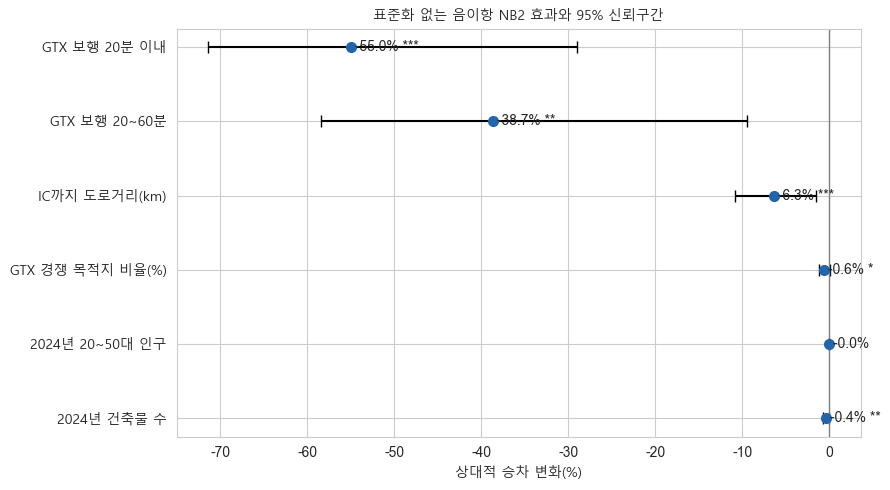

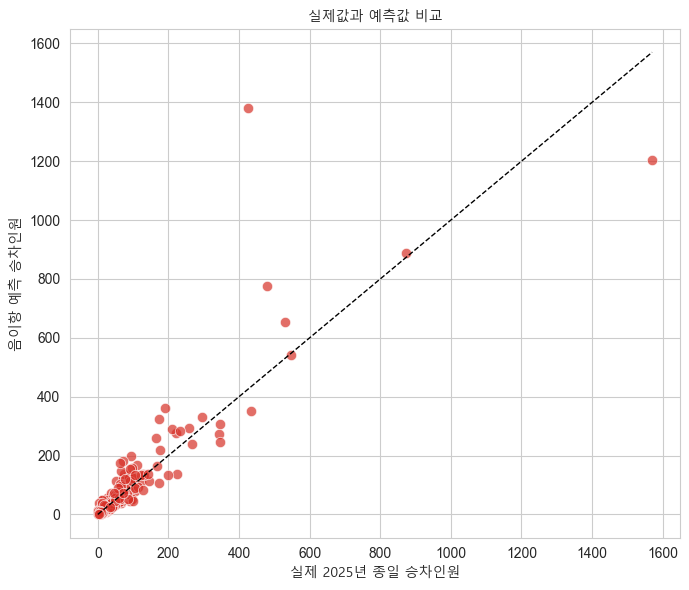

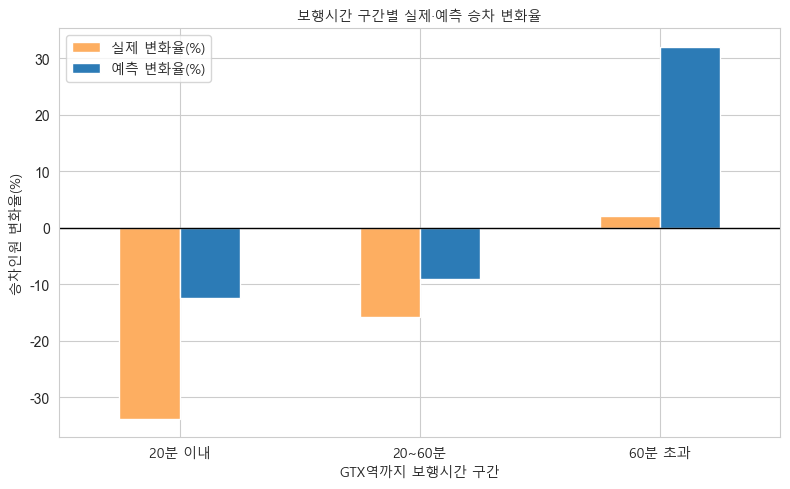

In [19]:
# Raw-unit NB2 model with dummy walking-time variables
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

cell_col = '\uc140 ID'
route_col = '\ub178\uc120'
RAW_FEATURES = ['walk_20', 'walk_20_60', 'ic_access', 'competing_share', 'pop_20_50', 'buildings']
RAW_LABELS = {
    'walk_20': 'GTX \ubcf4\ud589 20\ubd84 \uc774\ub0b4',
    'walk_20_60': 'GTX \ubcf4\ud589 20~60\ubd84',
    'ic_access': 'IC\uae4c\uc9c0 \ub3c4\ub85c\uac70\ub9ac(km)',
    'competing_share': 'GTX \uacbd\uc7c1 \ubaa9\uc801\uc9c0 \ube44\uc728(%)',
    'pop_20_50': '2024\ub144 20~50\ub300 \uc778\uad6c',
    'buildings': '2024\ub144 \uac74\ucd95\ubb3c \uc218'
}

f_raw = f[[cell_col, route_col, 'y2024', 'y2025'] + RAW_FEATURES].copy()
f_raw = f_raw[f_raw['y2024'] > 0].dropna(subset=RAW_FEATURES + ['y2024', 'y2025']).reset_index(drop=True)

x_raw = f_raw[RAW_FEATURES].apply(pd.to_numeric, errors='coerce')
route_raw = pd.get_dummies(f_raw[route_col], prefix='route', drop_first=True, dtype=float)
X_raw = sm.add_constant(pd.concat([x_raw, route_raw], axis=1), has_constant='add')
offset_raw = np.log(f_raw['y2024'])

pois_raw = sm.GLM(f_raw['y2025'], X_raw, family=sm.families.Poisson(), offset=offset_raw).fit()
nb_raw = NegativeBinomial(f_raw['y2025'], X_raw, offset=offset_raw, loglike_method='nb2')
nb_raw_fit = nb_raw.fit(
    start_params=np.r_[np.asarray(pois_raw.params), 0.2],
    method='bfgs', maxiter=5000, disp=False,
    cov_type='cluster',
    cov_kwds={'groups': pd.factorize(f_raw[cell_col])[0], 'use_correction': True}
)

print('===== Raw-unit Negative Binomial NB2 =====')
print('N:', len(f_raw), '| cells:', f_raw[cell_col].nunique(), '| routes:', f_raw[route_col].nunique())
print('converged:', nb_raw_fit.mle_retvals.get('converged'))
print('warnflag:', nb_raw_fit.mle_retvals.get('warnflag'))

ci_raw = nb_raw_fit.conf_int().loc[RAW_FEATURES]
raw_result = pd.DataFrame({
    '\ubcc0\uc218': [RAW_LABELS[v] for v in RAW_FEATURES],
    '\uacc4\uc218': [nb_raw_fit.params[v] for v in RAW_FEATURES],
    'IRR': [np.exp(nb_raw_fit.params[v]) for v in RAW_FEATURES],
    '\uc0c1\ub300\uc801 \uc2b9\ucc28 \ubcc0\ud654(%)': [(np.exp(nb_raw_fit.params[v]) - 1) * 100 for v in RAW_FEATURES],
    'p-value': [nb_raw_fit.pvalues[v] for v in RAW_FEATURES]
})
display(raw_result.round(4))

font_candidates = [Path(r'C:\\Windows\\Fonts\\malgun.ttf'), Path(r'C:\\Windows\\Fonts\\NanumGothic.ttf')]
font_path = next((p for p in font_candidates if p.exists()), None)
if font_path:
    fm.fontManager.addfont(str(font_path))
    font_prop = fm.FontProperties(fname=str(font_path))
    plt.rcParams['font.family'] = font_prop.get_name()
else:
    font_prop = None
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# 1. coefficient effect plot
plot_effect = raw_result.copy()
plot_effect['lower'] = [(np.exp(ci_raw.loc[v, 0]) - 1) * 100 for v in RAW_FEATURES]
plot_effect['upper'] = [(np.exp(ci_raw.loc[v, 1]) - 1) * 100 for v in RAW_FEATURES]
plot_effect = plot_effect.iloc[::-1].reset_index(drop=True)
y_pos = np.arange(len(plot_effect))
effect_col = '\uc0c1\ub300\uc801 \uc2b9\ucc28 \ubcc0\ud654(%)'
x = plot_effect[effect_col].to_numpy()
xerr = np.vstack([x - plot_effect['lower'].to_numpy(), plot_effect['upper'].to_numpy() - x])
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(x, y_pos, xerr=xerr, fmt='o', color='#2166ac', ecolor='black', capsize=4, markersize=7)
ax.axvline(0, color='gray', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_effect['\ubcc0\uc218'], fontproperties=font_prop)
ax.set_xlabel('\uc0c1\ub300\uc801 \uc2b9\ucc28 \ubcc0\ud654(%)', fontproperties=font_prop)
ax.set_title('\ud45c\uc900\ud654 \uc5c6\ub294 \uc74c\uc774\ud56d NB2 \ud6a8\uacfc\uc640 95% \uc2e0\ub8b0\uad6c\uac04', fontproperties=font_prop)
for i, row in plot_effect.iterrows():
    p = row['p-value']
    mark = '***' if p < .01 else '**' if p < .05 else '*' if p < .10 else ''
    ax.text(row[effect_col], i, f" {row[effect_col]:.1f}% {mark}", va='center')
plt.tight_layout()
plt.show()

# 2. actual vs predicted
f_raw['pred_y2025'] = nb_raw_fit.predict(X_raw, offset=offset_raw)
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=f_raw, x='y2025', y='pred_y2025', s=55, alpha=.7, color='#d73027', ax=ax)
max_value = max(f_raw['y2025'].max(), f_raw['pred_y2025'].max())
ax.plot([0, max_value], [0, max_value], '--', color='black', linewidth=1)
ax.set_xlabel('\uc2e4\uc81c 2025\ub144 \uc885\uc77c \uc2b9\ucc28\uc778\uc6d0', fontproperties=font_prop)
ax.set_ylabel('\uc74c\uc774\ud56d \uc608\uce21 \uc2b9\ucc28\uc778\uc6d0', fontproperties=font_prop)
ax.set_title('\uc2e4\uc81c\uac12\uacfc \uc608\uce21\uac12 \ube44\uad50', fontproperties=font_prop)
plt.tight_layout()
plt.show()

# 3. group-level actual vs predicted change rate
f_raw['walk_group'] = np.select(
    [f_raw['walk_20'] == 1, f_raw['walk_20_60'] == 1],
    ['20\ubd84 \uc774\ub0b4', '20~60\ubd84'],
    default='60\ubd84 \ucd08\uacfc'
)
g = f_raw.groupby('walk_group', sort=False)
actual_rate = g.apply(lambda z: (z['y2025'].sum() / z['y2024'].sum() - 1) * 100)
pred_rate = g.apply(lambda z: (z['pred_y2025'].sum() / z['y2024'].sum() - 1) * 100)
plot_df = pd.DataFrame({'\uc2e4\uc81c \ubcc0\ud654\uc728(%)': actual_rate, '\uc608\uce21 \ubcc0\ud654\uc728(%)': pred_rate}).reindex(['20\ubd84 \uc774\ub0b4', '20~60\ubd84', '60\ubd84 \ucd08\uacfc'])
ax = plot_df.plot(kind='bar', figsize=(8, 5), color=['#fdae61', '#2c7bb6'])
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('GTX\uc5ed\uae4c\uc9c0 \ubcf4\ud589\uc2dc\uac04 \uad6c\uac04', fontproperties=font_prop)
ax.set_ylabel('\uc2b9\ucc28\uc778\uc6d0 \ubcc0\ud654\uc728(%)', fontproperties=font_prop)
ax.set_title('\ubcf4\ud589\uc2dc\uac04 \uad6c\uac04\ubcc4 \uc2e4\uc81c\u00b7\uc608\uce21 \uc2b9\ucc28 \ubcc0\ud654\uc728', fontproperties=font_prop)
ax.legend(prop=font_prop)
plt.xticks(rotation=0, fontproperties=font_prop)
plt.tight_layout()
plt.show()


,변수,IRR,IRR 하한,IRR 상한,p-value
0,건축물 수,0.9962,0.9927,0.9998,0.0363
1,20~50대 인구,0.9999,0.9997,1.0002,0.5938
2,GTX 경쟁 목적지 비율,0.9942,0.9878,1.0008,0.0830
3,IC까지 도로거리,0.9368,0.8915,0.9844,0.0098
4,GTX 보행 20~60분,0.6133,0.4153,0.9057,0.0140
5,GTX 보행 20분 이내,0.4503,0.2853,0.7105,0.0006


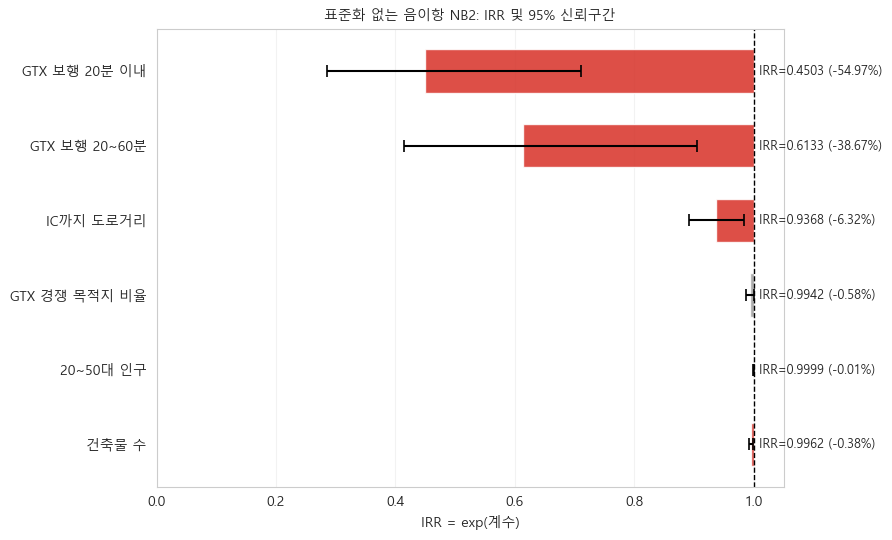

In [20]:
# ??? ?? ??? NB2 ??: IRR? 95% ????
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = Path(r"C:\Windows\Fonts\malgun.ttf")
font_prop = fm.FontProperties(fname=str(font_path))
fm.fontManager.addfont(str(font_path))
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

LABELS_RAW = {
    'walk_20': 'GTX \ubcf4\ud589 20\ubd84 \uc774\ub0b4',
    'walk_20_60': 'GTX \ubcf4\ud589 20~60\ubd84',
    'ic_access': 'IC\uae4c\uc9c0 \ub3c4\ub85c\uac70\ub9ac',
    'competing_share': 'GTX \uacbd\uc7c1 \ubaa9\uc801\uc9c0 \ube44\uc728',
    'pop_20_50': '20~50\ub300 \uc778\uad6c',
    'buildings': '\uac74\ucd95\ubb3c \uc218',
}

# ??? ?? ?? ??? ????
RAW_ORDER = ['walk_20', 'walk_20_60', 'ic_access', 'competing_share', 'pop_20_50', 'buildings']
ci_plot = nb_raw_fit.conf_int().loc[RAW_ORDER]
irr_table_raw = pd.DataFrame({
    '\ubcc0\uc218': [LABELS_RAW.get(v, v) for v in RAW_ORDER],
    'IRR': np.exp(nb_raw_fit.params.loc[RAW_ORDER].values),
    'IRR \ud558\ud55c': np.exp(ci_plot[0].values),
    'IRR \uc0c1\ud55c': np.exp(ci_plot[1].values),
    'p-value': nb_raw_fit.pvalues.loc[RAW_ORDER].values,
}).iloc[::-1].reset_index(drop=True)

display(irr_table_raw.round(4))

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(irr_table_raw))
x = irr_table_raw['IRR'].to_numpy()
xerr = np.vstack([
    x - irr_table_raw['IRR \ud558\ud55c'].to_numpy(),
    irr_table_raw['IRR \uc0c1\ud55c'].to_numpy() - x,
])
colors = ['#d73027' if p < 0.05 else '#9e9e9e' for p in irr_table_raw['p-value']]

ax.barh(y, x - 1, left=1, color=colors, alpha=0.85, height=0.58)
ax.errorbar(
    x, y, xerr=xerr, fmt='none', ecolor='black',
    capsize=4, elinewidth=1.5, capthick=1.2
)

# ??? ?? 0? ??? ??? ??? ? ??? ??
for i, row in irr_table_raw.iterrows():
    effect_pct = (row['IRR'] - 1) * 100
    ax.text(
        max(row['IRR'], 1) + 0.01, i,
        f"IRR={row['IRR']:.4f} ({effect_pct:+.2f}%)",
        va='center', fontsize=9
    )

ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_xlim(0, max(1.05, float(irr_table_raw['IRR \uc0c1\ud55c'].max()) * 1.05))
ax.set_yticks(y)
ax.set_yticklabels(irr_table_raw['\ubcc0\uc218'].tolist(), fontproperties=font_prop)
ax.set_xlabel('IRR = exp(\uacc4\uc218)', fontproperties=font_prop)
ax.set_title('\ud45c\uc900\ud654 \uc5c6\ub294 \uc74c\uc774\ud56d NB2: IRR \ubc0f 95% \uc2e0\ub8b0\uad6c\uac04', fontproperties=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()
